# Benchmark part 2: methods that keep the covariance in memory

All methods here store a d x d matrix and must give an up-to-date top-P basis after every batch:

| method | where the code comes from | extraction per batch |
|---|---|---|
| **Group EIG** (ours) | `group_eig.py` | greedy 2P x 2P block rotations on S = U^T C U |
| Pairwise EIG (ours, optional) | `pairwise_eig.py` | greedy 2x2 Jacobi rotations |
| Exact eigh, every K batches | `scipy.linalg.eigh(subset_by_index)` | dense solve |
| LOBPCG (scipy) | `scipy.sparse.linalg.lobpcg` | a few iterations, warm-started |
| LOBPCG (torch) | `torch.lobpcg` | same, different implementation |
| Lanczos (ARPACK) | `scipy.sparse.linalg.eigsh` | implicitly restarted Lanczos, warm vector `v0` |
| Riemannian trust-region | `pymanopt` (Grassmann manifold) | a few TR iterations on -tr(Q^T C Q) |
| Subspace iteration | textbook, `Q = qr(C @ Q)` | one power step, every K batches |

Setup, the same for every method:

- data shuffled once, first `MONITOR_ROWS` rows held out, centering with a running mean
- only the method's own update is timed; the held-out EVR is computed every `EVAL_EVERY` batches, untimed
- baselines start from the exact eigenvectors of the first batch (included in their time); ours uses the Householder warm start
- `C products` counts how many columns were multiplied by the d x d covariance, an implementation-independent measure of work (our methods do not multiply by C, their work is the rotations; n/a for exact eigh and torch LOBPCG, which do the work inside a library call)
- a method is skipped, not silently replaced, when its library does not support the size (torch LOBPCG needs d >= 3P, scipy LOBPCG d >= 5P)

Run the estimate cell first: it times a few batches of every method and prints the projected run time.

In [7]:
import json
import math
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.linalg as sla
from scipy.sparse.linalg import LinearOperator, eigsh, lobpcg
import torch

import data as ds
import group_eig
import pairwise_eig
from eig_warmstart import HouseholderWarmStart

try:
    import pymanopt
    from pymanopt.manifolds import Grassmann
    from pymanopt.optimizers import TrustRegions
    HAVE_PYMANOPT = True
except ImportError:
    HAVE_PYMANOPT = False
    print("pymanopt not installed - the Riemannian baseline is skipped (pip install pymanopt)")

# lobpcg warns on every call when maxiter is small; that is expected here
warnings.filterwarnings("ignore", message="(?s).*requested tolerance")

In [8]:
# "yearprediction" | "gas_sensor" | "synthetic" | "glove300" | "har"
# "isolet" | "fashion_mnist" | "news20" | "cifar10"
DATASETS = ["har", "isolet", "fashion_mnist", "news20"]

# (batch size, P) pairs to run
REGIMES = [(100, 90), (100, 50), (1000, 15)]

MONITOR_ROWS = 2000
MAX_SAMPLES = 30000          # samples used from each stream
SEED = 0
EVAL_EVERY = 10              # held-out EVR every k batches (and at the last one)

# ours
GROUP_STEPS = 1              # group steps per batch
INCLUDE_PAIRWISE = False
PAIRWISE_ROT_PER_DIM = 0.05  # pairwise rotations per batch = this * d

# baselines
EXACT_EVERY = 10             # exact eigh every k batches
LOBPCG_ITERS = 1
SUBSPACE_EVERY = [1, 5]      # one subspace iteration step every k batches
ARPACK_TOL = 1e-6
RTR_ITERS = 1                # Riemannian trust-region iterations per batch
RTR_MAXINNER = 20            # inner CG steps per TR iteration

RESULTS_FILE = "benchmark_part2_results.json"

In [9]:
def load_stream(name, batch):
    X_all = ds.load(name)
    rows = np.random.default_rng(SEED).permutation(X_all.shape[0])[:MONITOR_ROWS + MAX_SAMPLES]
    A = np.asarray(X_all[rows], dtype=np.float64)
    monitor = np.ascontiguousarray(A[:MONITOR_ROWS].T)
    stream = A[MONITOR_ROWS:].T
    batches = [np.ascontiguousarray(stream[:, s:s + batch]) for s in range(0, stream.shape[1], batch)]
    return batches, monitor


class RunningMean:
    '''Center each batch with its own mean plus one correction column, so that summing
    z z^T gives exactly the centered covariance of everything seen so far.'''

    def __init__(self, d):
        self.n = 0
        self.mu = np.zeros(d)

    def center(self, X):
        m = X.shape[1]
        mu_b = X.mean(axis=1)
        Z = X - mu_b[:, None]
        if self.n > 0:
            w = self.n * m / (self.n + m)
            Z = np.hstack([Z, math.sqrt(w) * (self.mu - mu_b)[:, None]])
        self.mu = (self.n * self.mu + m * mu_b) / (self.n + m)
        self.n += m
        return Z


def evr(Xc, Q):
    # Q has orthonormal columns, so the explained variance is ||Q^T X||^2 / ||X||^2
    return (np.linalg.norm(Q.T @ Xc) / np.linalg.norm(Xc)) ** 2


def eval_points(n_batches):
    idx = list(range(EVAL_EVERY - 1, n_batches, EVAL_EVERY))
    if not idx or idx[-1] != n_batches - 1:
        idx.append(n_batches - 1)
    return idx

In [10]:
class Ours:
    def __init__(self, est, warmstart):
        self.est = est
        self.warmstart = warmstart
        self.c_products = 0

    def partial_fit(self, Z):
        self.est.partial_fit(Z, warmstart=self.warmstart)

    def basis(self):
        return self.est.components_.T


class CovBaseline:
    '''Keeps C = sum z z^T. First batch: exact eigenvectors. Later batches: refine().'''

    def __init__(self, d, p):
        self.C = np.zeros((d, d))
        self.p = p
        self.Q = None
        self.k = 0
        self.c_products = 0

    def partial_fit(self, Z):
        self.C += Z @ np.ascontiguousarray(Z.T)
        if self.Q is None:
            d = self.C.shape[0]
            self.Q = np.ascontiguousarray(sla.eigh(self.C, subset_by_index=[d - self.p, d - 1])[1][:, ::-1])
        else:
            self.refine()
        self.k += 1

    def basis(self):
        return self.Q

    def C_op(self):
        # the covariance as an operator that counts the columns it is applied to
        d = self.C.shape[0]

        def matmat(X):
            X = np.asarray(X)
            self.c_products += 1 if X.ndim == 1 else X.shape[1]
            return self.C @ X

        return LinearOperator((d, d), matvec=matmat, matmat=matmat, dtype=np.float64)


class ExactEigh(CovBaseline):
    def __init__(self, d, p, every):
        super().__init__(d, p)
        self.every = every
        self.c_products = None       # dense solve, not counted in products

    def refine(self):
        if self.k % self.every == 0:
            d = self.C.shape[0]
            self.Q = np.ascontiguousarray(sla.eigh(self.C, subset_by_index=[d - self.p, d - 1])[1][:, ::-1])


class SubspaceIteration(CovBaseline):
    def __init__(self, d, p, every):
        super().__init__(d, p)
        self.every = every

    def refine(self):
        if self.k % self.every == 0:
            self.Q = np.linalg.qr(self.C @ self.Q)[0]
            self.c_products += self.p


class ScipyLOBPCG(CovBaseline):
    def __init__(self, d, p, n_iter):
        super().__init__(d, p)
        self.n_iter = n_iter

    def refine(self):
        _, self.Q = lobpcg(self.C_op(), self.Q, largest=True, maxiter=self.n_iter)


class TorchLOBPCG(CovBaseline):
    def __init__(self, d, p, n_iter):
        super().__init__(d, p)
        self.n_iter = n_iter
        self.c_products = None       # torch does the products internally, cannot count them

    def refine(self):
        # torch counts its initial Rayleigh-Ritz steps as iterations: niter = scipy maxiter + 2
        # gives the same iterate (checked on a test matrix), so both do the same LOBPCG steps.
        _, Q = torch.lobpcg(torch.from_numpy(self.C), k=self.p, X=torch.from_numpy(self.Q),
                            niter=self.n_iter + 2, largest=True)
        self.Q = Q.numpy()


class ArpackLanczos(CovBaseline):
    def __init__(self, d, p, tol):
        super().__init__(d, p)
        self.tol = tol

    def refine(self):
        v0 = self.Q.sum(axis=1)      # one start vector with weight on every previous eigenvector
        _, self.Q = eigsh(self.C_op(), k=self.p, which="LA", v0=v0, tol=self.tol)


class RiemannianTR(CovBaseline):
    def __init__(self, d, p, iters, maxinner):
        super().__init__(d, p)
        self.maxinner = maxinner
        self.manifold = Grassmann(d, p)
        self.optimizer = TrustRegions(max_iterations=iters, miniter=1, verbosity=0)

    def refine(self):
        # minimize -tr(Q^T C Q) / tr(C) on the Grassmann manifold (scaled for conditioning)
        C, scale, manifold = self.C, 1.0 / np.trace(self.C), self.manifold

        @pymanopt.function.numpy(manifold)
        def cost(Q):
            self.c_products += Q.shape[1]
            return -scale * np.sum(Q * (C @ Q))

        @pymanopt.function.numpy(manifold)
        def grad(Q):
            self.c_products += Q.shape[1]
            return -2.0 * scale * (C @ Q)

        @pymanopt.function.numpy(manifold)
        def hess(Q, E):
            self.c_products += E.shape[1]
            return -2.0 * scale * (C @ E)

        problem = pymanopt.Problem(manifold, cost, euclidean_gradient=grad, euclidean_hessian=hess)
        self.Q = self.optimizer.run(problem, initial_point=self.Q, maxinner=self.maxinner).point


def make_methods(d, p):
    '''(name, factory, reason if skipped)'''
    warm = HouseholderWarmStart(krylov_dim=p)
    m = [("Group EIG (ours)",
          lambda: Ours(group_eig.OnlineGroupEIG(n=d, p=p, k_per_batch=GROUP_STEPS, top_m=max(p, 32)), warm),
          None)]
    if INCLUDE_PAIRWISE:
        G = max(1, round(PAIRWISE_ROT_PER_DIM * d))
        m.append(("Pairwise EIG (ours)",
                  lambda: Ours(pairwise_eig.OnlineEIG(n=d, p=p, k_per_batch=G), warm), None))
    m.append((f"Exact eigh, every {EXACT_EVERY}", lambda: ExactEigh(d, p, EXACT_EVERY), None))
    m.append(("LOBPCG (scipy)", lambda: ScipyLOBPCG(d, p, LOBPCG_ITERS),
              None if d >= 5 * p else f"needs d >= 5P ({d} < {5 * p})"))
    m.append(("LOBPCG (torch)", lambda: TorchLOBPCG(d, p, LOBPCG_ITERS),
              None if d >= 3 * p else f"needs d >= 3P ({d} < {3 * p})"))
    m.append(("Lanczos (ARPACK)", lambda: ArpackLanczos(d, p, ARPACK_TOL),
              None if p < d - 1 else "needs P < d - 1"))
    m.append(("Riemannian TR (pymanopt)", lambda: RiemannianTR(d, p, RTR_ITERS, RTR_MAXINNER),
              None if HAVE_PYMANOPT else "pymanopt not installed"))
    for k in SUBSPACE_EVERY:
        m.append((f"Subspace iteration, every {k}", lambda k=k: SubspaceIteration(d, p, k), None))
    return m

In [11]:
def reference(batches, monitor, p, points):
    '''Exact EVR at the evaluation points (untimed).'''
    d = batches[0].shape[0]
    mean, C, out = RunningMean(d), np.zeros((d, d)), {}
    for b, X in enumerate(batches):
        Z = mean.center(X)
        C += Z @ Z.T
        if b in points:
            V = sla.eigh(C, subset_by_index=[d - p, d - 1])[1]
            out[b] = evr(monitor - mean.mu[:, None], V)
    return out


def run_method(factory, batches, monitor, points, n_batches=None):
    d = batches[0].shape[0]
    est, mean = factory(), RunningMean(d)
    t, times, evrs = 0.0, [], []
    for b, X in enumerate(batches[:n_batches]):
        t0 = time.perf_counter()
        est.partial_fit(mean.center(X))
        t += time.perf_counter() - t0
        if b in points:
            times.append(t)
            evrs.append(evr(monitor - mean.mu[:, None], est.basis()))
    return dict(time=t, times=times, evrs=evrs, c_products=est.c_products)

## Estimate the run time first

Times the first 4 batches of every method on every dataset and regime, and projects the full run
(methods + untimed reference and evaluation). This takes well under a minute.

In [12]:
total = 0.0
for name in DATASETS:
    for batch, p in REGIMES:
        batches, monitor = load_stream(name, batch)
        d, nb = batches[0].shape[0], len(batches)
        if p >= d // 2:
            print(f"{name:14s} batch={batch:5d} P={p:3d}: skipped, P too large for d={d}")
            continue
        est = 0.0
        for label, factory, why in make_methods(d, p):
            if why is None:
                r = run_method(factory, batches, monitor, points=set(), n_batches=4)
                est += r["time"] / 4 * nb
        t0 = time.perf_counter()
        sla.eigh(batches[0] @ batches[0].T, subset_by_index=[d - p, d - 1])
        est += (time.perf_counter() - t0) * len(eval_points(nb)) * 2     # reference + eval, roughly
        total += est
        print(f"{name:14s} batch={batch:5d} P={p:3d}: d={d}, {nb} batches, about {est:5.0f}s")
print(f"projected total: about {total / 60:.1f} min")

har            batch=  100 P= 90: d=561, 83 batches, about    32s
har            batch=  100 P= 50: d=561, 83 batches, about    25s
har            batch= 1000 P= 15: d=561, 9 batches, about     3s
isolet         batch=  100 P= 90: d=617, 58 batches, about    23s
isolet         batch=  100 P= 50: d=617, 58 batches, about    19s
isolet         batch= 1000 P= 15: d=617, 6 batches, about     3s
fashion_mnist  batch=  100 P= 90: d=784, 300 batches, about   171s
fashion_mnist  batch=  100 P= 50: d=784, 300 batches, about   128s
fashion_mnist  batch= 1000 P= 15: d=784, 30 batches, about    14s
news20         batch=  100 P= 90: d=1000, 169 batches, about   121s
news20         batch=  100 P= 50: d=1000, 169 batches, about    87s
news20         batch= 1000 P= 15: d=1000, 17 batches, about    12s
projected total: about 10.6 min


## Run

In [13]:
try:
    results = json.load(open(RESULTS_FILE))
except FileNotFoundError:
    results = {}

for name in DATASETS:
    for batch, p in REGIMES:
        batches, monitor = load_stream(name, batch)
        d, nb = batches[0].shape[0], len(batches)
        if p >= d // 2:
            continue
        key = f"{name}|batch={batch}|P={p}"
        points = eval_points(nb)
        ref = reference(batches, monitor, p, set(points))
        exact = [ref[b] for b in points]
        samples = [min((b + 1) * batch, MAX_SAMPLES) for b in points]
        print(f"\n{key}  (d={d}, {nb} batches, exact EVR at end {exact[-1]:.6f})")
        results[key] = dict(d=d, samples=samples, exact=exact, methods={})
        for label, factory, why in make_methods(d, p):
            if why is not None:
                print(f"  {label:30s} skipped: {why}")
                continue
            r = run_method(factory, batches, monitor, set(points))
            deficit = np.array(exact) - np.array(r["evrs"])
            r.update(final_evr=r["evrs"][-1], mean_deficit=float(deficit.mean()),
                     worst_deficit=float(deficit.max()))
            results[key]["methods"][label] = r
            print(f"  {label:30s} {r['time']:7.2f}s  EVR {r['final_evr']:.6f}  "
                  f"mean deficit {r['mean_deficit']:.1e}  C products {r['c_products'] if r['c_products'] is not None else 'n/a'}", flush=True)
        json.dump(results, open(RESULTS_FILE, "w"), indent=1)


har|batch=100|P=90  (d=561, 83 batches, exact EVR at end 0.965164)
  Group EIG (ours)                  1.09s  EVR 0.965156  mean deficit 1.9e-04  C products 0
  Exact eigh, every 10              1.02s  EVR 0.965143  mean deficit 4.0e-03  C products n/a
  LOBPCG (scipy)                    5.79s  EVR 0.965164  mean deficit 8.4e-08  C products 29430
  LOBPCG (torch)                    2.44s  EVR 0.965164  mean deficit 8.4e-08  C products n/a
  Lanczos (ARPACK)                  2.86s  EVR 0.965164  mean deficit 0.0e+00  C products 14924
  Riemannian TR (pymanopt)          7.05s  EVR 0.965164  mean deficit 7.9e-05  C products 301500
  Subspace iteration, every 1       0.73s  EVR 0.965155  mean deficit 6.4e-05  C products 7380
  Subspace iteration, every 5       0.34s  EVR 0.965063  mean deficit 1.0e-03  C products 1440

har|batch=100|P=50  (d=561, 83 batches, exact EVR at end 0.926448)
  Group EIG (ours)                  0.63s  EVR 0.926420  mean deficit 9.1e-04  C products 0
  Exact eigh,

## Summary table

In [14]:
rows = []
for key, r in results.items():
    for label, m in r["methods"].items():
        rows.append(dict(setting=key, method=label, time_s=round(m["time"], 3),
                         final_evr=round(m["final_evr"], 6), exact_evr=round(r["exact"][-1], 6),
                         mean_deficit=m["mean_deficit"], worst_deficit=m["worst_deficit"],
                         c_products=m["c_products"]))
table = pd.DataFrame(rows)
pd.set_option("display.float_format", lambda x: f"{x:.3g}")
table.sort_values(["setting", "time_s"])

,setting,method,time_s,final_evr,exact_evr,mean_deficit,worst_deficit,c_products
71,fashion_mnist|batch=1000|P=15,"Subspace iteration, every 5",0.79,0.757,0.757,0.000596,0.000878,75
66,fashion_mnist|batch=1000|P=15,LOBPCG (scipy),0.792,0.757,0.757,-1.26e-05,-2.18e-06,1.74e+03
70,fashion_mnist|batch=1000|P=15,"Subspace iteration, every 1",0.87,0.757,0.757,8.3e-05,0.000102,435
65,fashion_mnist|batch=1000|P=15,"Exact eigh, every 10",1.06,0.757,0.757,0.00155,0.00421,NaN
64,fashion_mnist|batch=1000|P=15,Group EIG (ours),1.1,0.745,0.757,0.0194,0.0272,0
...,...,...,...,...,...,...,...,...
73,news20|batch=100|P=90,"Exact eigh, every 10",5.07,0.344,0.345,0.00954,0.093,NaN
75,news20|batch=100|P=90,LOBPCG (torch),9.11,0.345,0.345,4.31e-05,0.000231,NaN
76,news20|batch=100|P=90,Lanczos (ARPACK),16.8,0.345,0.345,4.8e-12,6.46e-11,4.55e+04
74,news20|batch=100|P=90,LOBPCG (scipy),17.1,0.345,0.345,4.31e-05,0.000231,6.04e+04


## EVR vs fit time, one figure per regime

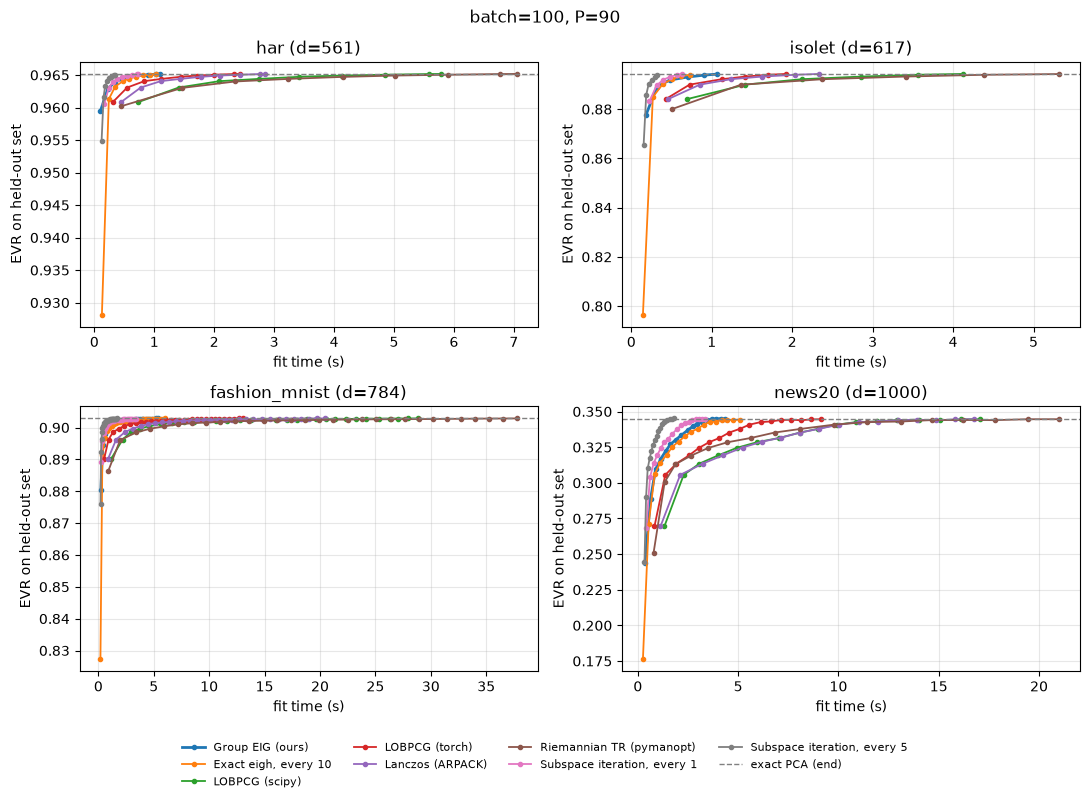

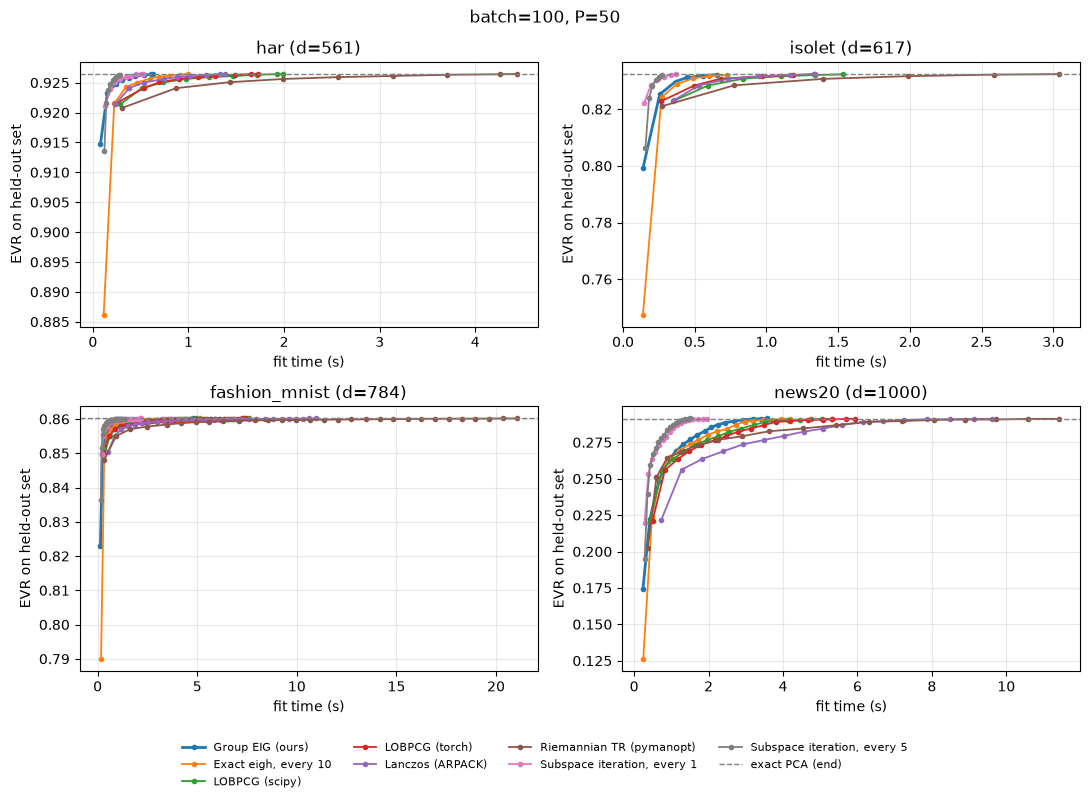

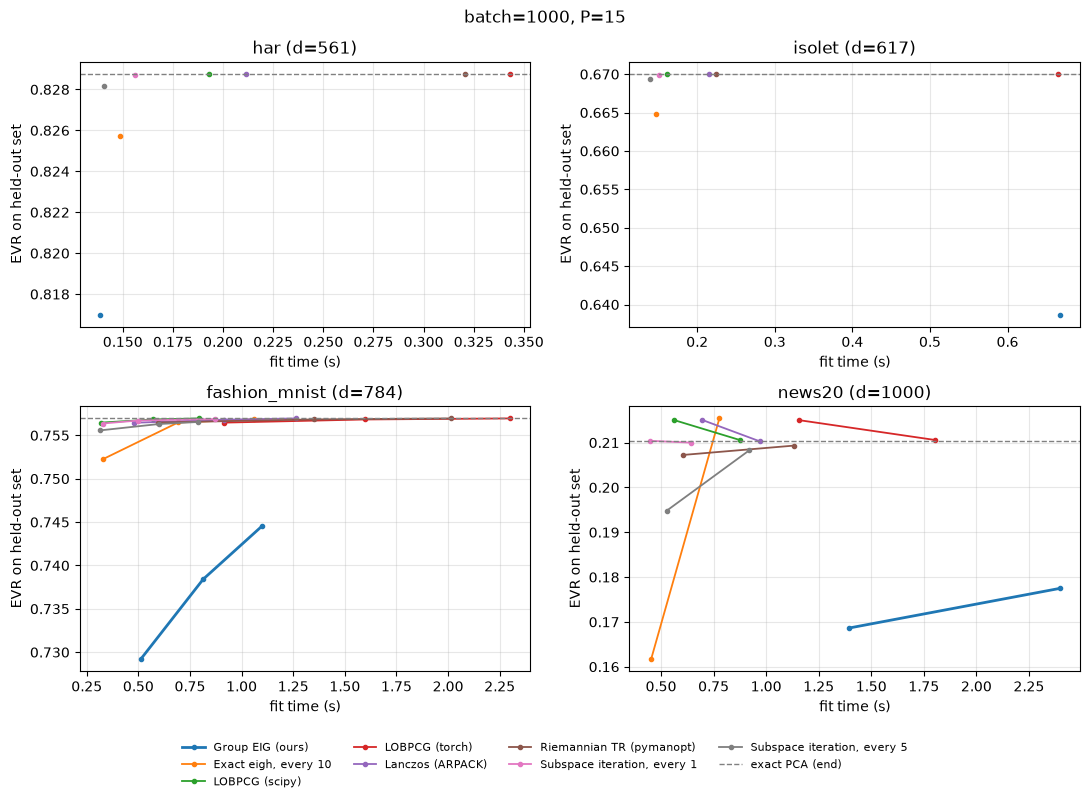

In [17]:
for batch, p in REGIMES:
    keys = [k for k in results if k.endswith(f"|batch={batch}|P={p}")]
    if not keys:
        continue
    ncols = 2
    nrows = math.ceil(len(keys) / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(11, 4 * nrows), squeeze=False)
    for ax in axes.flat[len(keys):]:
        ax.set_visible(False)
    for ax, key in zip(axes.flat, keys):
        r = results[key]
        for label, m in r["methods"].items():
            ax.plot(m["times"], m["evrs"], "o-", lw=2 if "ours" in label else 1.3, ms=3, label=label)
        ax.axhline(r["exact"][-1], color="gray", ls="--", lw=1, label="exact PCA (end)")
        ax.set_title(key.split("|")[0] + f" (d={r['d']})")
        ax.set_xlabel("fit time (s)")
        ax.set_ylabel("EVR on held-out set")
        ax.grid(alpha=0.3)
    handles, labels = axes.flat[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="lower center", ncol=4, fontsize=8, frameon=False)
    fig.suptitle(f"batch={batch}, P={p}")
    plt.tight_layout(rect=(0, 0.08, 1, 1))
    plt.show()


## EVR vs samples, one figure per regime

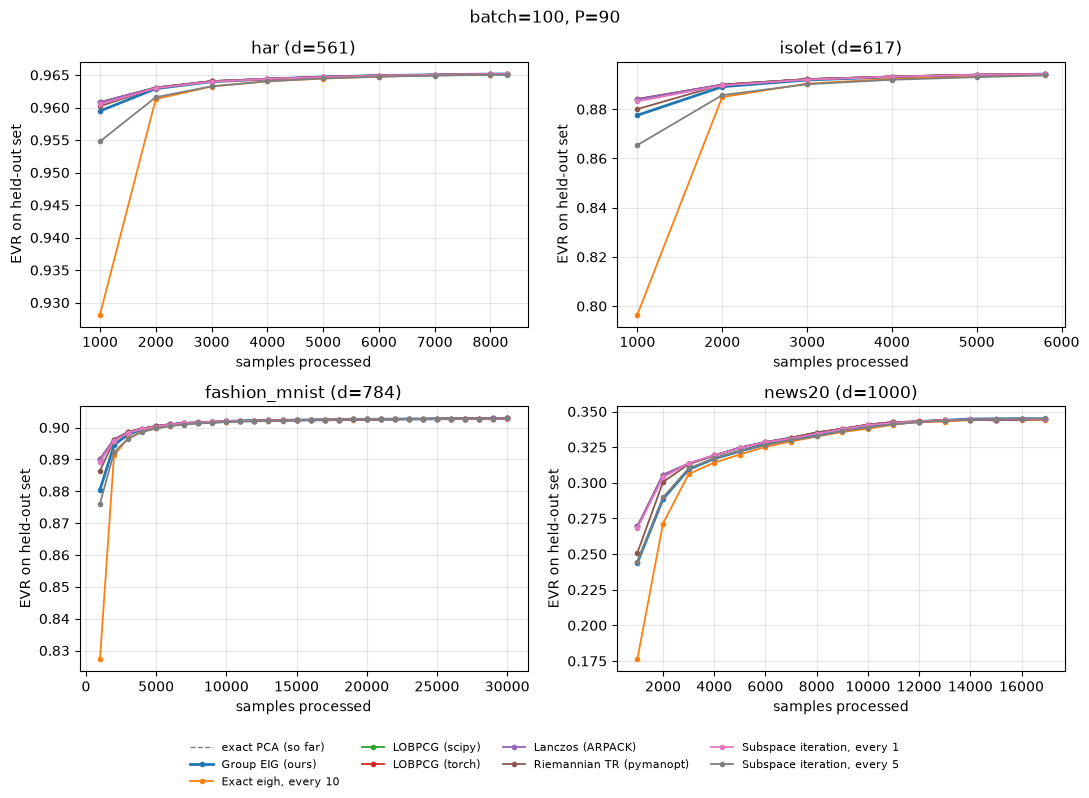

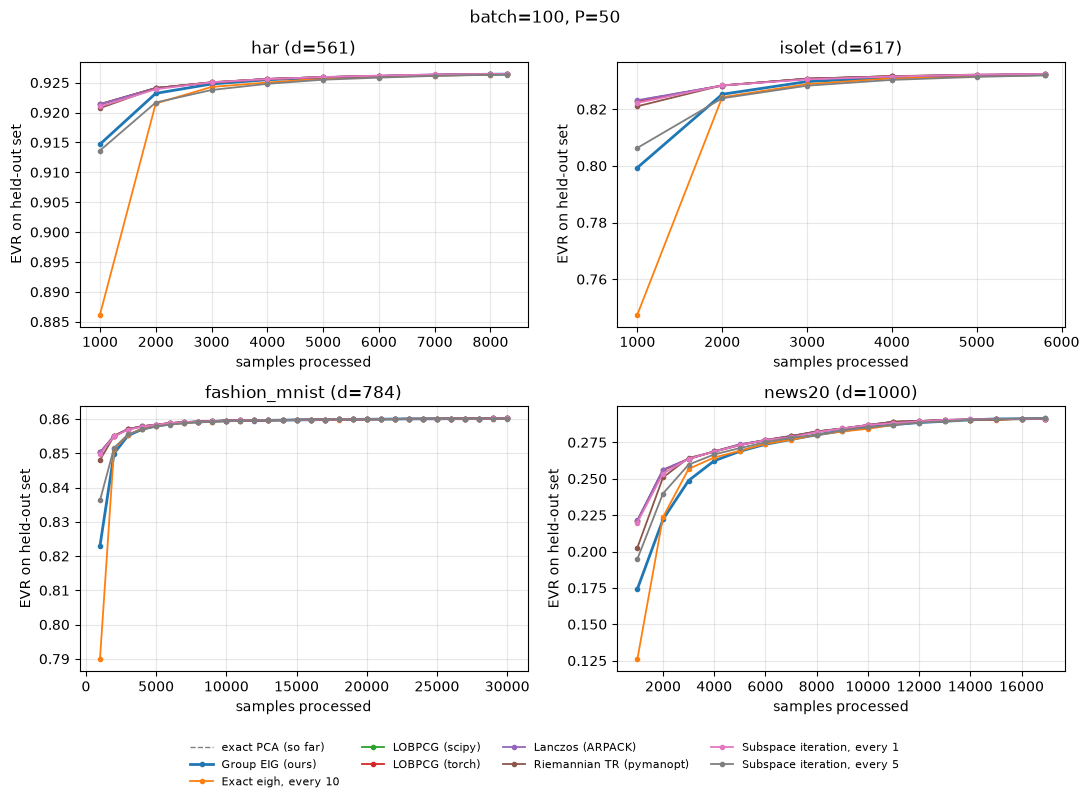

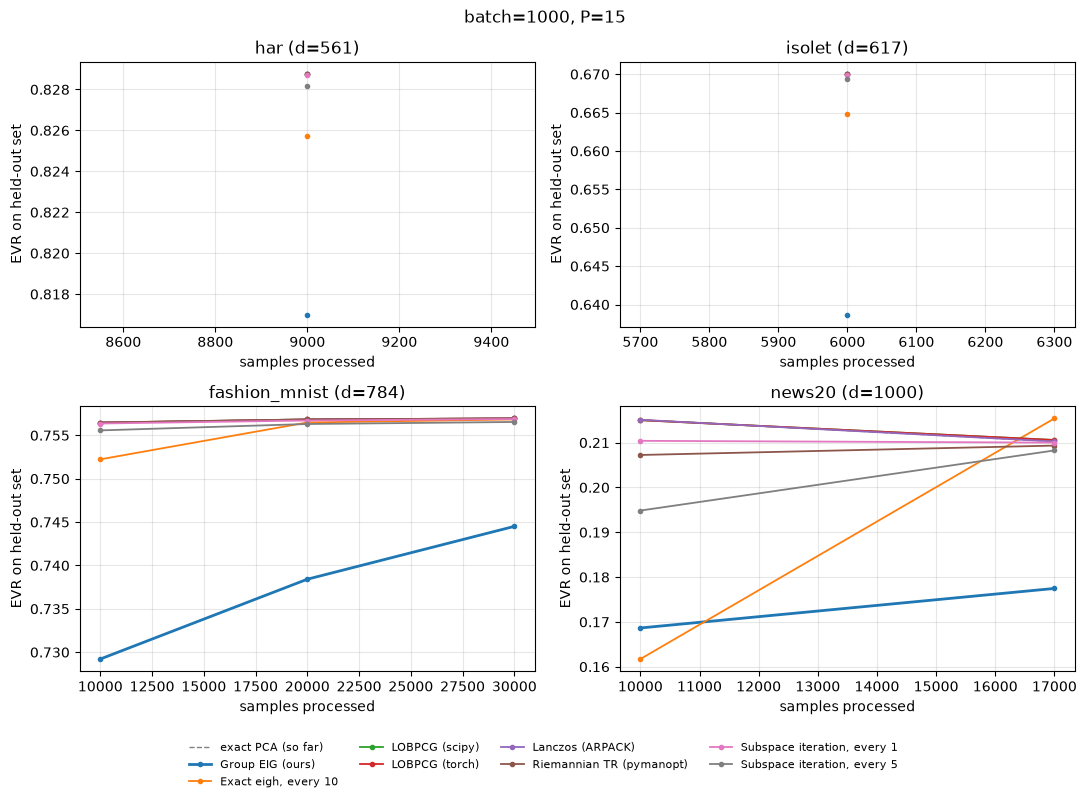

In [18]:
for batch, p in REGIMES:
    keys = [k for k in results if k.endswith(f"|batch={batch}|P={p}")]
    if not keys:
        continue
    ncols = 2
    nrows = math.ceil(len(keys) / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(11, 4 * nrows), squeeze=False)
    for ax in axes.flat[len(keys):]:
        ax.set_visible(False)
    for ax, key in zip(axes.flat, keys):
        r = results[key]
        ax.plot(r["samples"], r["exact"], color="gray", ls="--", lw=1, label="exact PCA (so far)")
        for label, m in r["methods"].items():
            ax.plot(r["samples"], m["evrs"], "o-", lw=2 if "ours" in label else 1.3, ms=3, label=label)
        ax.set_title(key.split("|")[0] + f" (d={r['d']})")
        ax.set_xlabel("samples processed")
        ax.set_ylabel("EVR on held-out set")
        ax.grid(alpha=0.3)
    handles, labels = axes.flat[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="lower center", ncol=4, fontsize=8, frameon=False)
    fig.suptitle(f"batch={batch}, P={p}")
    plt.tight_layout(rect=(0, 0.08, 1, 1))
    plt.show()


Notes:

- `mean deficit` is exact EVR minus the method's EVR, averaged over the evaluation points; it
  penalizes methods whose answer lags during the stream, not only at the end.
- Results are appended to `RESULTS_FILE` after every dataset/regime, so an interrupted run keeps
  what finished. Delete the file to start fresh.
- The Riemannian baseline needs `pip install pymanopt`.